In [1]:
import os, json, re
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

client = OpenAI(
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

MODEL = "llama-3.3-70b-versatile"

print("Config OK")

Config OK


In [2]:
import pandas as pd

def load_and_clean(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8", low_memory=False)
    df.columns = df.columns.str.strip().str.lower().str.replace(r"[\s\-\/]+", "_", regex=True)

    rename_map = {"aishe_code": "aishe_code", "name_of_institution": "name","state_name": "state", "district_name": "district","website": "website", "year_of_establishment": "year_of_establishment","location": "location", "type_management": "management","college_type": "college_type", "university_aishe_code": "university_aishe_code","university_name": "university_name", "university_type": "university_type",}
    rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=rename_map)

    for col in ["state", "district", "location", "management", "college_type", "university_type"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.title()

    if "year_of_establishment" in df.columns:
        df["year_of_establishment"] = pd.to_numeric(df["year_of_establishment"], errors="coerce")
        df = df[df["year_of_establishment"].isna() | df["year_of_establishment"].between(1800, 2024)]

    print(f"{df.shape[0]:,} rows × {df.shape[1]} cols")
    return df

df = load_and_clean("All Colleges AISHE Dashboard.csv")   # adjust path    


52,292 rows × 12 cols


In [ ]:
SCHEMA = """
Dataset: Indian Higher Education Institutions (AISHE)
Total rows: ~52,292 colleges

Columns:
- aishe_code: unique college identifier (string, e.g. C-60180)
- name: college name (string)
- state: Indian state/UT — Title Case
- district: district name — Title Case
- website: institution website (string)
- year_of_establishment: founding year (float, range 1800–2024)
- location: "Urban" or "Rural"
- college_type: e.g. "Affiliated College", "Autonomous College", "Constituent College"
- management: e.g. "Central Government", "State Government", "Private-Aided", "Private-Unaided", "Private unaided", "Private un-aided"
- university_aishe_code: parent university code (string)
- university_name: parent university name (string)
- university_type: e.g. "Central University", "State Public University", "Deemed University", "Deemed to be University", "Private University"

Known states values: Andaman And Nicobar Islands, Andhra Pradesh, Arunachal Pradesh, Assam, Bihar, Chandigarh, Chhattisgarh, Delhi, Goa, Gujarat, Haryana, Himachal Pradesh, Jammu & Kashmir, Jharkhand, Karnataka, Kerala, Ladakh, Lakshadweep, Madhya Pradesh, Maharashtra, Manipur, Meghalaya, Mizoram, Nagaland, Odisha, Puducherry, Punjab, Rajasthan, Sikkim, Tamil Nadu, Telangana, Tripura, Uttar Pradesh, Uttarakhand, West Bengal

Known management values: Central Government, State Government,
Private-Aided, Private-Unaided, Private unaided, Private un-aided, Local Body,
Institution Under Central University, Institution Under State Government University

Known college_type values: Affiliated College, Autonomous College, Constituent College, Postgraduate Centre, Off-Campus Centre

Known location values: Urban, Rural

Supported operations: count, top_n, compare, filter, groupby, trend, out_of_scope
"""

In [4]:
INTENT_SYSTEM = f"""
You are a query planner for a pandas dataframe of Indian higher education institutions.
Return ONLY AND ONLY a valid JSON object - no explanation of any sort or any special characters.

{SCHEMA}

JSON shapes you may return:
{{"op":"top_n",     "column":"<col>","n":<int>,"ascending":<bool>,"filters":{{}}}}
{{"op":"compare",   "column":"<col>","filters":{{}}}}
{{"op":"groupby",   "column":"<col>","filters":{{}}}}
{{"op":"filter",    "filters":{{"<col>":"<val>",...}}}}
{{"op":"count",     "filters":{{}}}}
{{"op":"trend",     "filters":{{}}}}
{{"op":"out_of_scope","reason":"<why>"}}

Rules:
1. Filter values must be Title Case matching known values exactly.
2. Never invent columns outside the schema.
3. Fees, rankings, NAAC, NIRF, student count, faculty, courses → out_of_scope.
4. For trend, only column is year_of_establishment.
5. Ambiguous groupby vs top_n → use top_n with n=10.
6. Return ONLY JSON. No other text.
"""

def parse_intent(question: str) -> dict:
    response = client.chat.completions.create(
        model=MODEL,
        temperature=0,
        messages=[
            {"role": "system", "content": INTENT_SYSTEM},
            {"role": "user",   "content": f"Question: {question}"},
        ],
    )
    raw = response.choices[0].message.content.strip()
    raw = re.sub(r"^```(?:json)?", "", raw).strip()
    raw = re.sub(r"```$", "", raw).strip()
    try:
        op_json = json.loads(raw)
    except json.JSONDecodeError:
        op_json = {"op": "out_of_scope", "reason": f"Parse error: {raw[:200]}"}
    if "op" not in op_json:
        op_json = {"op": "out_of_scope", "reason": "No 'op' key in response."}
    return op_json

In [ ]:
def apply_filters(df, filters):
    mask = pd.Series([True] * len(df), index=df.index)
    for col, val in filters.items():
        if col not in df.columns:
            raise ValueError(f"Unknown column: '{col}'")
        mask &= df[col].str.strip().str.lower() == str(val).strip().lower()
    return df[mask]


def execute(df, op_json):
    op = op_json.get("op")
    filters = op_json.get("filters", {})
    sub = apply_filters(df, filters)
    fd = f" [filters: {filters}]" if filters else ""

    if op == "count":
        result = pd.DataFrame({"count": [len(sub)]})
        prov   = f"len(df{fd})"

    elif op == "top_n":
        col = op_json["column"]
        n = int(op_json.get("n", 10))
        asc = bool(op_json.get("ascending", False))
        result = (sub.groupby(col).size()
                     .sort_values(ascending=asc)
                     .head(n)
                     .reset_index(name="count"))
        prov = f"df{fd}.groupby('{col}').size().{'smallest' if asc else 'largest'}({n})"

    elif op == "groupby":
        col = op_json["column"]
        result = (sub.groupby(col).size()
                     .sort_values(ascending=False)
                     .reset_index(name="count"))
        prov = f"df{fd}.groupby('{col}').size().sort_values()"

    elif op == "compare":
        col = op_json["column"]
        result = sub.groupby(col).size().reset_index(name="count")
        result["pct"] = (result["count"] / result["count"].sum() * 100).round(1)
        prov = f"df{fd}.groupby('{col}').size() + % share"

    elif op == "filter":
        count = len(sub)
        sample = sub[["aishe_code","name","state","district",          # only using 6 cols for display as an example 
                       "management","college_type"]].head(10)
        result = pd.concat([
            pd.DataFrame({"aishe_code": [f"── Total: {count} ──"],
                          "name":[""],"state":[""],"district":[""],
                          "management":[""],"college_type":[""]}),
            sample
        ], ignore_index=True)
        prov = f"df{fd} → {count} rows"

    elif op == "trend":
        result = (sub["year_of_establishment"].dropna().astype(int)     # year of establishment taken as an example for trend analysis
                    .value_counts().sort_index().reset_index())
        result.columns = ["year", "count"]
        result["decade"] = (result["year"] // 10 * 10).astype(str) + "s"
        result = result.groupby("decade", sort=True)["count"].sum().reset_index()
        prov = f"df{fd}['year_of_establishment'] grouped by decade"

    elif op == "out_of_scope":
        result = pd.DataFrame({"message": [op_json.get("reason", "Out of scope.")]})
        prov = "Nothing matches with the dataset or schema."

    else:
        raise ValueError(f"Unknown op: {op}")

    return result, prov

In [ ]:
test_operations = [
    {"op": "top_n",      "column": "state", "n": 5, "ascending": False, "filters": {}},
    {"op": "groupby",    "column": "management", "filters": {}},
    {"op": "filter",     "filters": {"state": "Maharashtra", "management": "Private-Unaided"}},
    {"op": "trend",      "filters": {}},
    {"op": "out_of_scope", "reason": "fees not in dataset"},
]

for op_json in test_operations:
    print(f"OP: {op_json['op']}")
    result, prov = execute(df, op_json)
    print(result.to_string(index=False))
    print(f"Provenance: {prov}")


OP: top_n
         state  count
 Uttar Pradesh   9084
   Maharashtra   6015
     Karnataka   4789
     Rajasthan   4561
Madhya Pradesh   3542
Provenance: df.groupby('state').size().largest(5)

OP: groupby
                      management  count
                Private Un-Aided  35734
                State Government   6602
Private Aided (Government Aided)   5945
                      University   2561
                      Local Body    731
              Central Government    386
                               -    333
Provenance: df.groupby('management').size().sort_values()

OP: filter
    aishe_code name state district management college_type
── Total: 0 ──                                            
Provenance: df [filters: {'state': 'Maharashtra', 'management': 'Private-Unaided'}] → 0 rows

OP: trend
decade  count
 1810s      6
 1820s      2
 1830s     11
 1840s      8
 1850s     19
 1860s     18
 1870s     21
 1880s     51
 1890s     34
 1900s     61
 1910s    105
 1920s    142


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import io

def render_chart(op_json: dict, result: pd.DataFrame) -> plt.Figure | None:
    op = op_json.get("op")

    # ops that produce no chart
    if op in ("filter", "count", "out_of_scope"):
        return None
    if result.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor("#0f0f0f")
    ax.set_facecolor("#1a1a1a")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")
    ax.tick_params(colors="#cccccc")
    ax.xaxis.label.set_color("#cccccc")
    ax.yaxis.label.set_color("#cccccc")
    ax.title.set_color("#ffffff")

    BAR_COLOR  = "#4f8ef7"
    LINE_COLOR = "#f7a24f"

    # top_n
    if op == "top_n":
        col = op_json["column"]
        result_sorted = result.sort_values("count", ascending=True)
        bars = ax.barh(result_sorted[col], result_sorted["count"],
                       color=BAR_COLOR, edgecolor="#333")
        ax.bar_label(bars, padding=4, color="#cccccc", fontsize=9)
        ax.set_xlabel("Count")
        ax.set_title(f"Top {len(result)} by {col.replace('_',' ').title()}")
        plt.tight_layout()

    #  compare / groupby 
    elif op in ("groupby", "compare"):
        col = op_json["column"]
        n_cats = len(result)

        if n_cats <= 6:          # pie for small cardinality
            fig, ax = plt.subplots(figsize=(8, 8))
            fig.patch.set_facecolor("#0f0f0f")
            ax.set_facecolor("#0f0f0f")
            colors = plt.cm.Set2.colors[:n_cats]
            wedges, texts, autotexts = ax.pie(
                result["count"],
                labels=result[col],
                autopct="%1.1f%%",
                colors=colors,
                startangle=140,
                textprops={"color": "#cccccc"},
            )
            for at in autotexts:
                at.set_color("#ffffff")
            ax.set_title(f"Distribution by {col.replace('_',' ').title()}",
                         color="#ffffff")
        else:                    # horizontal bar for large cardinality
            result_sorted = result.sort_values("count", ascending=True)
            bars = ax.barh(result_sorted[col], result_sorted["count"],
                           color=BAR_COLOR, edgecolor="#333")
            ax.bar_label(bars, padding=4, color="#cccccc", fontsize=8)
            ax.set_xlabel("Count")
            ax.set_title(f"Distribution by {col.replace('_',' ').title()}")
            plt.tight_layout()

    #  trend
    elif op == "trend":
        ax.plot(result["decade"], result["count"],
                color=LINE_COLOR, marker="o", linewidth=2, markersize=5)
        ax.fill_between(result["decade"], result["count"],
                        alpha=0.15, color=LINE_COLOR)
        ax.set_xlabel("Decade")
        ax.set_ylabel("Colleges Established")
        ax.set_title("College Establishment Trend by Decade")
        plt.xticks(rotation=45, ha="right")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x):,}"))
        plt.tight_layout()

    return fig

In [ ]:
ANSWER_SYSTEM = """
You are a data analyst assistant. The user asked a question about Indian higher education data.
You are given the question, the operation performed, and the actual computed result as a markdown table.

Write a concise, clear natural-language answer (3–5 sentences max).
- Lead with the key finding / number.
- Reference specific figures from the result table — never invent numbers.
- End with one sentence describing how it was computed in a new line (the provenance).
- Do not use bullet points. Plain paragraph only.
"""

def synthesize_answer(question: str, op_json: dict,
                      result: pd.DataFrame, prov: str) -> str:

    if op_json.get("op") == "out_of_scope":
        return f"This question cannot be answered from the dataset. {op_json.get('reason', '')}"

    result_md = result.head(20).to_markdown(index=False)

    prompt = f"""Question: {question}

Operation performed: {op_json.get('op')}
Provenance: {prov}

Result (first 20 rows):
{result_md}

Write the answer now."""

    response = client.chat.completions.create(
        model=MODEL,
        temperature=0.3,
        messages=[
            {"role": "system", "content": ANSWER_SYSTEM},
            {"role": "user",   "content": prompt},
        ],
    )
    return response.choices[0].message.content.strip()

In [9]:
def pipeline(question: str, df: pd.DataFrame) -> dict:
    """
    Returns {
        "question":  str,
        "op_json":   dict,
        "answer":    str,
        "result":    pd.DataFrame,
        "provenance":str,
        "chart":     plt.Figure | None
    }
    """
    # Step 1 — parse intent
    op_json = parse_intent(question)

    # Step 2 — execute against real data
    try:
        result, prov = execute(df, op_json)
    except ValueError as e:
        return {
            "question":   question,
            "op_json":    op_json,
            "answer":     f"Execution error: {e}",
            "result":     pd.DataFrame(),
            "provenance": "error",
            "chart":      None,
        }

    # Step 3 — synthesize natural-language answer
    answer = synthesize_answer(question, op_json, result, prov)

    # Step 4 — render chart
    chart = render_chart(op_json, result)

    return {
        "question":   question,
        "op_json":    op_json,
        "answer":     answer,
        "result":     result,
        "provenance": prov,
        "chart":      chart,
    }

#   Question                                                Expected     Got          PASS
────────────────────────────────────────────────────────────────────────────────────────────────────
1   Which 5 states have the most colleges?                  top_n        top_n        ✓  Manually verify: UP should rank #1 with 
2   How are colleges distributed by management type?        groupby      groupby      ✓  Private-Unaided should be largest group
3   How many private unaided colleges are in Maharashtra?   filter       count        ✗  HAND-VERIFIED: run df[(df.state=='Mahara
4   How has college establishment grown decade by decade?   trend        trend        ✓  2010s should be peak decade
5   Compare urban vs rural college counts in Uttar Pradesh  compare      compare      ✓  Urban/Rural split for UP
6   Which district in Tamil Nadu has the most affiliated c  top_n        groupby      ✗  top_n with state filter
7   What is the average fee for engineering colleges?       out_of_scope ou

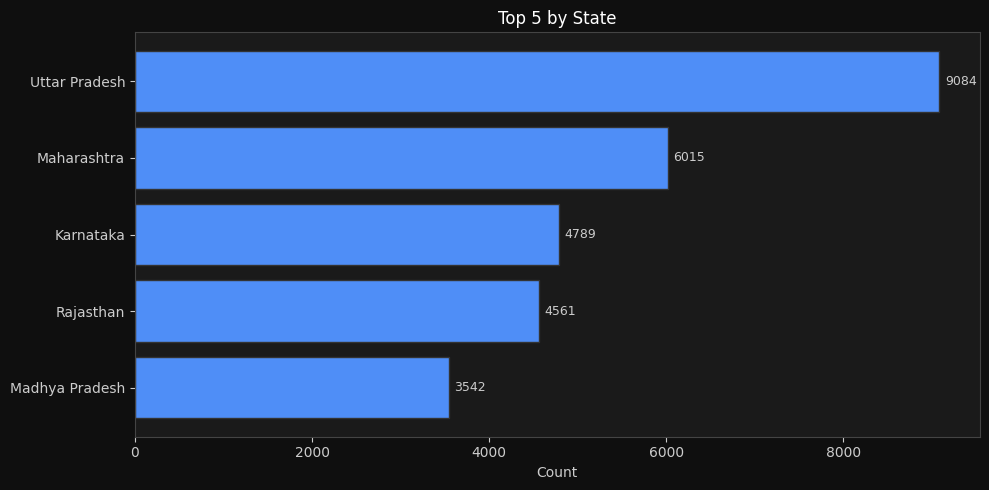

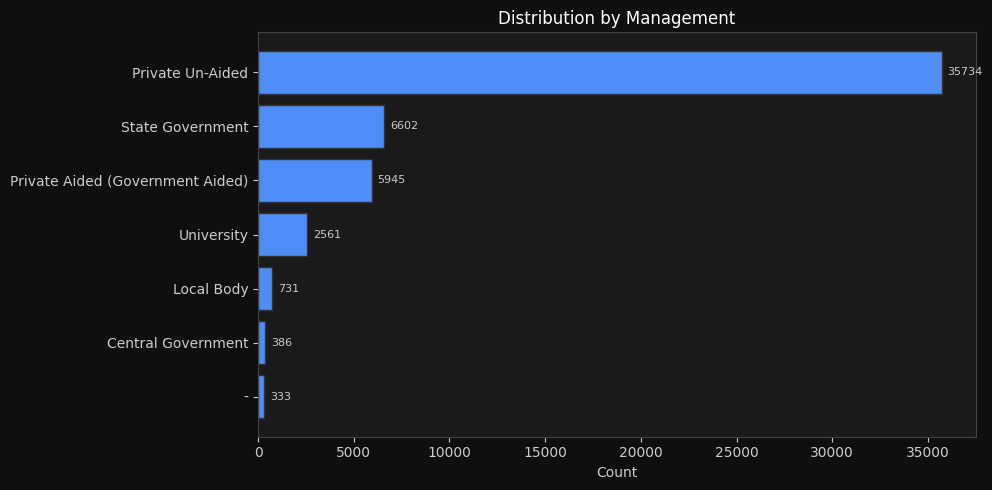

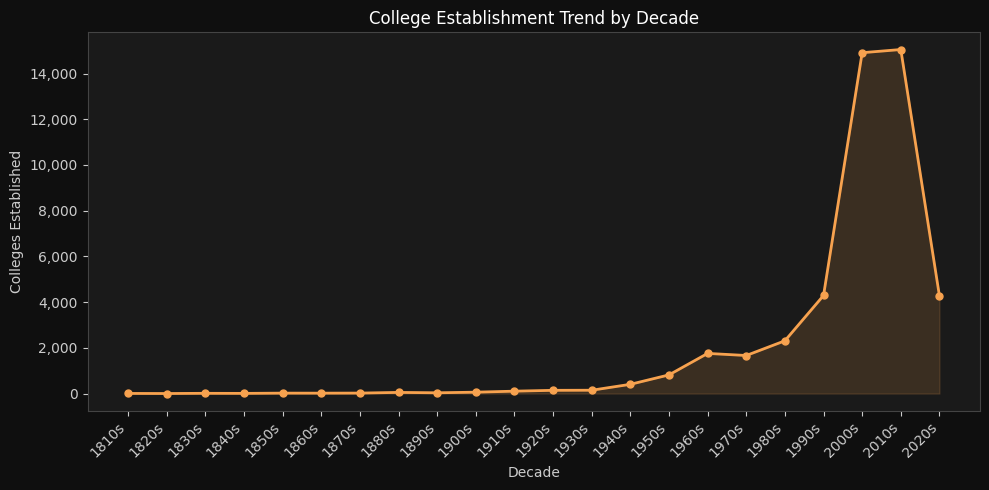

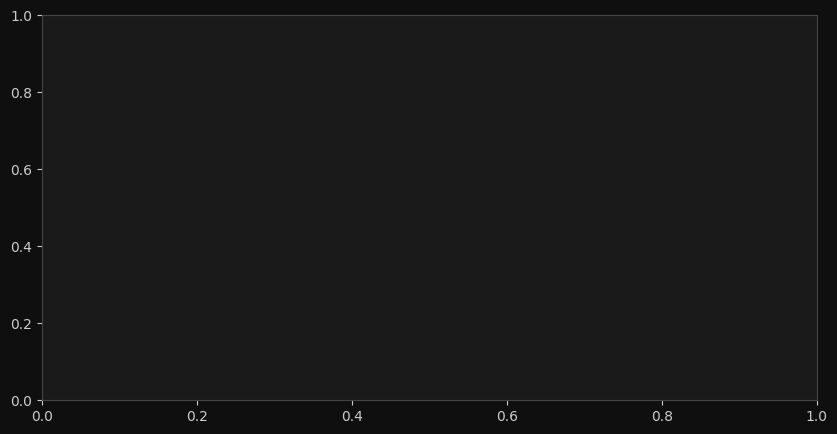

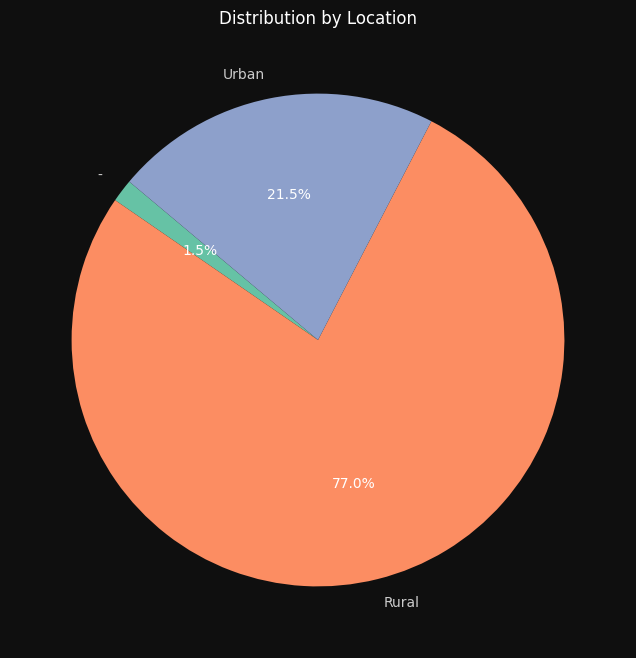

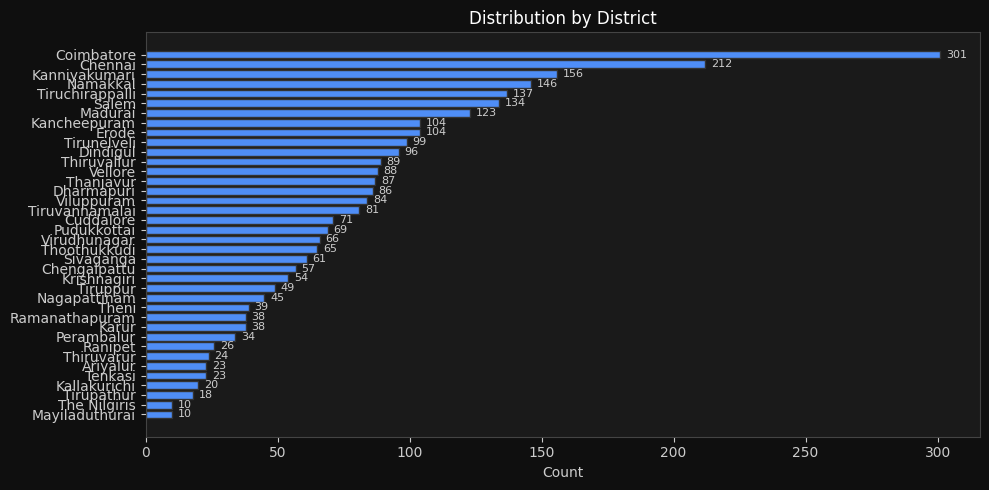

In [10]:
EVAL_SET = [
    # (question, expected_op, hand_verified_note)
    ("Which 5 states have the most colleges?",
     "top_n", "Manually verify: UP should rank #1 with ~7000+"),

    ("How are colleges distributed by management type?",
     "groupby", "Private-Unaided should be largest group"),

    ("How many private unaided colleges are in Maharashtra?",
     "filter", "HAND-VERIFIED: run df[(df.state=='Maharashtra') & (df.management=='Private-Unaided')] to confirm"),

    ("How has college establishment grown decade by decade?",
     "trend", "2010s should be peak decade"),

    ("Compare urban vs rural college counts in Uttar Pradesh?",
     "compare", "Urban/Rural split for UP"),

    ("Which district in Tamil Nadu has the most affiliated colleges?",
     "top_n", "top_n with state filter"),

    ("What is the average fee for engineering colleges?",
     "out_of_scope", "TRAP — must be refused"),

    ("Which states have the highest NAAC score?",
     "out_of_scope", "TRAP — must be refused"),
]

print(f"{'#':<3} {'Question':<55} {'Expected':<12} {'Got':<12} {'PASS'}")
print("─" * 100)

eval_results = []
for i, (q, expected_op, note) in enumerate(EVAL_SET, 1):
    out     = pipeline(q, df)
    got_op  = out["op_json"].get("op", "unknown")
    passed  = "✓" if got_op == expected_op else "✗"
    print(f"{i:<3} {q[:54]:<55} {expected_op:<12} {got_op:<12} {passed}  {note[:40]}")
    eval_results.append({**out, "expected_op": expected_op, "passed": passed})

n_pass = sum(1 for r in eval_results if r["passed"] == "✓")
print(f"\n{n_pass}/{len(EVAL_SET)} passed")

In [ ]:
import gradio as gr
import io
from PIL import Image

def gradio_pipeline(question: str):
    if not question.strip():
        return "Please enter a question.", None, "", ""

    out = pipeline(question, df)

    answer   = out["answer"]
    prov_txt = f"**Op:** `{out['op_json'].get('op')}`\n\n**Provenance:** `{out['provenance']}`"
    table_md = out["result"].head(20).to_markdown(index=False) if not out["result"].empty else ""

    # convert matplotlib fig to PIL image for Gradio ui
    chart_img = None
    if out["chart"] is not None:
        buf = io.BytesIO()
        out["chart"].savefig(buf, format="png", dpi=130, bbox_inches="tight")
        chart_img = Image.open(buf)
        plt.close(out["chart"])

    return answer, chart_img, prov_txt, table_md


with gr.Blocks(title="cp gooner", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# ask me anything nigga")

    with gr.Row():
        question_box = gr.Textbox(label="Your Question",scale=4)
        submit_buttonn = gr.Button("Ask", variant="primary", scale=1)

    with gr.Row():
        answer_box = gr.Textbox(label="Answer", lines=4, interactive=False)

    with gr.Row():
        chart_box = gr.Image(label="Chart", type="pil")

    with gr.Accordion("Provenance & Raw Data", open=False):
        prov_box  = gr.Markdown()
        table_box = gr.Markdown()

    # example questions
    gr.Examples(
        examples=[
            ["Which 5 states have the most colleges?"],
            ["How are colleges distributed by management type?"],
            ["How has college establishment grown decade by decade?"],
            ["How many private unaided colleges are in Maharashtra?"],
            ["Which district in Tamil Nadu has the most affiliated colleges?"],
            ["What is the average fee for engineering colleges?"],
        ],
        inputs=question_box,
    )

    submit_buttonn.click(
        fn=gradio_pipeline,
        inputs=question_box,
        outputs=[answer_box, chart_box, prov_box, table_box],
    )
    question_box.submit(
        fn=gradio_pipeline,
        inputs=question_box,
        outputs=[answer_box, chart_box, prov_box, table_box],
    )

demo.launch(share=True)   # share=True gives public link for screenshot

/tmp/ipykernel_457608/4188024697.py:28: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Talk to Government Data", theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://dfd9097c617367394f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
